# Objetivo 4 v2 — Entrenamiento GPU (Corregido segun PPI)
**Correcciones vs v1:**
- HQC-CNN: encoding RY + entrelazamiento circular
- HQCINN-deep: 6 qubits (Akpinar et al.)
- ResNet-18: fc = Linear(512, n_classes) directo
- batch=32 para ResNet-18, batch=16 para HQCNN
- Class weighting activado en AMBOS datasets
- IC 95% via 5-fold CV estratificado (segun PPI)

**Resultados v1 (referencia):**
- Chest: todos los modelos F1>0.91, sin diferencias significativas (ANOVA p>>0.05)
- Lung: HQCNN colapsaron (F1~0.23) por batch=64 + encoding incorrecto. ResNet-18 F1=0.95

## 0 · Instalacion

In [1]:
import subprocess,sys
subprocess.run([sys.executable,'-m','pip','install','-q','torch','torchvision','--index-url','https://download.pytorch.org/whl/cu128'],check=False)
subprocess.run([sys.executable,'-m','pip','install','-q','pennylane>=0.38','pennylane-lightning','scikit-learn','pandas','matplotlib','seaborn','tqdm'],check=False)
import torch; print('PyTorch:',torch.__version__)
print('CUDA:',torch.cuda.is_available())
if torch.cuda.is_available(): print('GPU:',torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


## 1 · Imports y seed

In [2]:
import os,random,time,json
from pathlib import Path
from itertools import combinations
import numpy as np,pandas as pd
import matplotlib.pyplot as plt,seaborn as sns
import torch,torch.nn as nn
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18,ResNet18_Weights
from torch.utils.data import DataLoader,WeightedRandomSampler
import pennylane as qml
from pennylane.qnn import TorchLayer
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,roc_auc_score,recall_score
from sklearn.model_selection import StratifiedKFold
from scipy import stats
SEED=42
random.seed(SEED);np.random.seed(SEED)
torch.manual_seed(SEED);torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark=True
torch.backends.cudnn.deterministic=False
torch.backends.cuda.matmul.allow_tf32=True
torch.backends.cudnn.allow_tf32=True
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert DEVICE.type=='cuda','GPU no detectada'
print('Device:',DEVICE,'|',torch.cuda.get_device_name(0))


Device: cuda | NVIDIA GeForce RTX 5060 Laptop GPU


## 2 · Rutas y transforms

In [3]:
BASE_DIR=Path(os.getcwd())
CHEST_OUT=BASE_DIR/'etl_output'/'chest_xray'
LUNG_OUT=BASE_DIR/'etl_output'/'lung_cancer'
CKPT_DIR=BASE_DIR/'checkpoints_gpu_v2';CKPT_DIR.mkdir(exist_ok=True)
IMG_SIZE=(128,128);MEAN=[0.485,0.456,0.406];STD=[0.229,0.224,0.225]
tfm_tr=T.Compose([T.Resize(IMG_SIZE),T.Grayscale(num_output_channels=3),T.RandomRotation(10),T.RandomHorizontalFlip(),T.ColorJitter(brightness=0.15),T.RandomAffine(degrees=0,scale=(0.90,1.10)),T.ToTensor(),T.Normalize(MEAN,STD)])
tfm_ev=T.Compose([T.Resize(IMG_SIZE),T.Grayscale(num_output_channels=3),T.ToTensor(),T.Normalize(MEAN,STD)])
N_CHEST=2;N_LUNG=3
CHEST_NAMES=['NORMAL','PNEUMONIA'];LUNG_NAMES=['Benign','Malignant','Normal']


## 3 · Class weights (ambos datasets segun PPI)

In [4]:
def get_class_weights(root):
    ds=ImageFolder(Path(root)/'train')
    tgts=torch.tensor(ds.targets)
    cw=(1.0/torch.bincount(tgts).float())
    return (cw/cw.sum()).to(DEVICE)

chest_cw=get_class_weights(CHEST_OUT)
lung_cw=get_class_weights(LUNG_OUT)
print('Chest class weights:',chest_cw)
print('Lung  class weights:',lung_cw)


Chest class weights: tensor([0.7297, 0.2703], device='cuda:0')
Lung  class weights: tensor([0.6654, 0.1426, 0.1921], device='cuda:0')


## 4 · Modelos (corregidos)

In [5]:
N_Q_SHALLOW=4; N_Q_DEEP=6

def get_qdev(n):
    try: return qml.device('lightning.qubit',wires=n)
    except: return qml.device('default.qubit',wires=n)

# ResNet-18: fc = Linear(512, n_classes) segun PPI
def build_resnet18(nc):
    m=resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    m.fc=nn.Linear(m.fc.in_features,nc)
    return m

# HQC-CNN: encoding RY + entrelazamiento circular (Dong et al., 2023)
dev_hqccnn=get_qdev(4)
@qml.qnode(dev_hqccnn,interface='torch',diff_method='adjoint')
def circuit_hqccnn(inputs,weights_rx,weights_ry):
    qml.AngleEmbedding(inputs,wires=range(4),rotation='Y')
    for q in range(4): qml.RX(weights_rx[q],wires=q); qml.RY(weights_ry[q],wires=q)
    for q in range(4): qml.CNOT(wires=[q,(q+1)%4])
    return [qml.expval(qml.PauliZ(i)) for i in range(4)]

class HQCCNN(nn.Module):
    def __init__(self,nc):
        super().__init__()
        self.feat=nn.Sequential(nn.Conv2d(3,16,3,padding=1),nn.BatchNorm2d(16),nn.ReLU(),nn.MaxPool2d(2),nn.Conv2d(16,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(),nn.MaxPool2d(2),nn.Conv2d(32,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(),nn.AdaptiveAvgPool2d((4,4)))
        self.pre_q=nn.Sequential(nn.Linear(64*4*4,64),nn.ReLU(),nn.Linear(64,4),nn.Tanh())
        self.ql=TorchLayer(circuit_hqccnn,{'weights_rx':(4,),'weights_ry':(4,)})
        self.cls=nn.Linear(4,nc)
    def forward(self,x):
        dv=x.device; x=self.feat(x).flatten(1)
        qi=self.pre_q(x).float().cpu()*torch.pi
        return self.cls(self.ql(qi).to(dv).to(x.dtype))

# PEQML: BasicEntanglerLayers + RY (Abdur & Kim, 2025)
dev_peqml=get_qdev(4)
@qml.qnode(dev_peqml,interface='torch',diff_method='adjoint')
def circuit_peqml(inputs,weights):
    qml.AngleEmbedding(inputs,wires=range(4),rotation='Y')
    qml.BasicEntanglerLayers(weights,wires=range(4))
    return [qml.expval(qml.PauliZ(i)) for i in range(4)]

class PEQML(nn.Module):
    def __init__(self,nc):
        super().__init__()
        def dw(ic,oc,s=1): return nn.Sequential(nn.Conv2d(ic,ic,3,stride=s,padding=1,groups=ic,bias=False),nn.Conv2d(ic,oc,1,bias=False),nn.BatchNorm2d(oc),nn.ReLU6())
        self.feat=nn.Sequential(nn.Conv2d(3,8,3,stride=2,padding=1,bias=False),nn.BatchNorm2d(8),nn.ReLU6(),dw(8,16,2),dw(16,32,2),dw(32,32,2),nn.AdaptiveAvgPool2d((2,2)))
        self.pre_q=nn.Sequential(nn.Linear(128,4),nn.Tanh())
        self.ql=TorchLayer(circuit_peqml,{'weights':(2,4)})
        self.cls=nn.Linear(4,nc)
    def forward(self,x):
        dv=x.device; x=self.feat(x).flatten(1)
        qi=self.pre_q(x).float().cpu()*torch.pi
        return self.cls(self.ql(qi).to(dv).to(x.dtype))

# HQCINN: shallow=4q/1capa  deep=6q/3capas (Akpinar et al., 2025)
def build_hqcinn_qlayer(nq,nl,ent='linear'):
    dev=get_qdev(nq)
    def entangle(wires,et):
        n=len(wires)
        if et=='linear':    [qml.CNOT(wires=[wires[i],wires[i+1]]) for i in range(n-1)]
        elif et=='circular':[qml.CNOT(wires=[wires[i],wires[(i+1)%n]]) for i in range(n)]
        elif et=='full':    [qml.CNOT(wires=[wires[i],wires[j]]) for i in range(n) for j in range(i+1,n)]
    @qml.qnode(dev,interface='torch',diff_method='adjoint')
    def circuit(inputs,weights_rx,weights_ry,weights_rz):
        qml.AngleEmbedding(inputs,wires=range(nq),rotation='X')
        for l in range(nl):
            for q in range(nq): qml.RX(weights_rx[l,q],wires=q); qml.RY(weights_ry[l,q],wires=q); qml.RZ(weights_rz[l,q],wires=q)
            entangle(list(range(nq)),ent)
        return [qml.expval(qml.PauliZ(i)) for i in range(nq)]
    ws={k:(nl,nq) for k in ['weights_rx','weights_ry','weights_rz']}
    return TorchLayer(circuit,ws)

class HQCINN(nn.Module):
    def __init__(self,nc,variant='shallow',entanglement='linear'):
        super().__init__()
        nq,nl={'shallow':(N_Q_SHALLOW,1),'deep':(N_Q_DEEP,3)}[variant]
        self.nq=nq
        self.feat=nn.Sequential(nn.Conv2d(3,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(),nn.MaxPool2d(2),nn.Conv2d(32,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(),nn.MaxPool2d(2),nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(),nn.AdaptiveAvgPool2d((2,2)))
        self.pre_q=nn.Sequential(nn.Linear(128*2*2,nq),nn.Tanh())
        self.ql=build_hqcinn_qlayer(nq,nl,entanglement)
        self.cls=nn.Linear(nq,nc)
    def forward(self,x):
        dv=x.device; x=self.feat(x).flatten(1)
        qi=self.pre_q(x).float().cpu()*torch.pi
        return self.cls(self.ql(qi).to(dv).to(x.dtype))

def build_model(name,nc):
    if name=='resnet18': return build_resnet18(nc)
    elif name=='hqccnn': return HQCCNN(nc)
    elif name=='peqml': return PEQML(nc)
    elif name=='hqcinn_shallow': return HQCINN(nc,variant='shallow')
    elif name=='hqcinn_deep': return HQCINN(nc,variant='deep')
    else: raise ValueError(name)

MODEL_NAMES=['resnet18','hqccnn','peqml','hqcinn_shallow','hqcinn_deep']
print('Modelos listos. Qubits: HQC-CNN=4, PEQML=4, HQCINN-shallow=4, HQCINN-deep=6')


Modelos listos. Qubits: HQC-CNN=4, PEQML=4, HQCINN-shallow=4, HQCINN-deep=6


## 5 · Funciones de entrenamiento (corregidas)

In [6]:
# batch=32 para ResNet-18, batch=16 para HQCNN (segun PPI)
BS_CLASSICAL=32; BS_QUANTUM=16

def make_loaders(root,weighted=False,bs=32):
    root=Path(root)
    ds_tr=ImageFolder(root/'train',transform=tfm_tr)
    ds_va=ImageFolder(root/'val',transform=tfm_ev)
    ds_te=ImageFolder(root/'test',transform=tfm_ev)
    kw=dict(num_workers=4,pin_memory=True,persistent_workers=True)
    if weighted:
        tgts=torch.tensor(ds_tr.targets)
        sw=(1.0/torch.bincount(tgts).float())[tgts]
        ltr=DataLoader(ds_tr,batch_size=bs,sampler=WeightedRandomSampler(sw,len(sw),True),**kw)
    else:
        ltr=DataLoader(ds_tr,batch_size=bs,shuffle=True,**kw)
    lva=DataLoader(ds_va,batch_size=bs,shuffle=False,**kw)
    lte=DataLoader(ds_te,batch_size=bs,shuffle=False,**kw)
    return ltr,lva,lte,ds_tr.class_to_idx

# class weights para AMBOS datasets (segun PPI)
def get_class_weights(root):
    ds=ImageFolder(Path(root)/'train')
    tgts=torch.tensor(ds.targets)
    cw=(1.0/torch.bincount(tgts).float())
    return (cw/cw.sum()).to(DEVICE)

def train_one(model,tr_l,va_l,cw=None,max_ep=50,patience=5,ckpt=None):
    model=model.to(DEVICE)
    crit=nn.CrossEntropyLoss(weight=cw)
    opt=torch.optim.Adam(model.parameters(),lr=1e-3)
    sch=torch.optim.lr_scheduler.MultiStepLR(opt,milestones=[10],gamma=0.1)
    scaler=torch.amp.GradScaler('cuda')
    hist={'train_loss':[],'val_loss':[],'val_acc':[],'val_f1':[]}
    best_f1,no_imp=0.0,0
    for ep in range(1,max_ep+1):
        model.train();tloss=0.0;t0=time.time()
        for imgs,lbls in tqdm(tr_l,desc='Ep '+str(ep),leave=False):
            imgs,lbls=imgs.to(DEVICE,non_blocking=True),lbls.to(DEVICE,non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda'): logits=model(imgs)
            loss=crit(logits.float(),lbls)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tloss+=loss.item()*imgs.size(0)
        sch.step(); avg_tr=tloss/len(tr_l.dataset); ep_t=time.time()-t0
        model.eval();vloss,preds,labs=0.0,[],[]
        with torch.no_grad():
            for imgs,lbls in va_l:
                imgs,lbls=imgs.to(DEVICE,non_blocking=True),lbls.to(DEVICE,non_blocking=True)
                with torch.amp.autocast('cuda'): logits=model(imgs)
                vloss+=crit(logits.float(),lbls).item()*imgs.size(0)
                preds.extend(logits.argmax(1).cpu().numpy()); labs.extend(lbls.cpu().numpy())
        avg_va=vloss/len(va_l.dataset)
        acc=sum(p==l for p,l in zip(preds,labs))/len(labs)
        f1=f1_score(labs,preds,average='macro',zero_division=0)
        hist['train_loss'].append(avg_tr);hist['val_loss'].append(avg_va)
        hist['val_acc'].append(acc);hist['val_f1'].append(f1)
        print('Ep {:3d} | {:.1f}s | tr={:.4f} | va={:.4f} | acc={:.4f} | F1={:.4f}'.format(ep,ep_t,avg_tr,avg_va,acc,f1))
        if f1>best_f1:
            best_f1,no_imp=f1,0
            if ckpt: torch.save(model.state_dict(),ckpt)
        else:
            no_imp+=1
            if no_imp>=patience: print('Early stopping ep',ep); break
    return hist

def compute_metrics(model,te_l,cls_names,mname):
    model=model.to(DEVICE).eval()
    preds,labs,probs=[],[],[]
    t0=time.time()
    with torch.no_grad():
        for imgs,lbls in te_l:
            with torch.amp.autocast('cuda'): logits=model(imgs.to(DEVICE,non_blocking=True))
            probs.extend(torch.softmax(logits.float(),1).cpu().numpy())
            preds.extend(logits.argmax(1).cpu().numpy()); labs.extend(lbls.numpy())
    inf_ms=(time.time()-t0)/len(labs)*1000
    nc=len(cls_names); acc=accuracy_score(labs,preds)
    f1m=f1_score(labs,preds,average='macro',zero_division=0)
    sens=recall_score(labs,preds,average='macro',zero_division=0)
    cm=confusion_matrix(labs,preds)
    sl=[]
    for i in range(nc):
        TP=cm[i,i];FN=cm[i,:].sum()-TP;FP=cm[:,i].sum()-TP;TN=cm.sum()-TP-FN-FP
        sl.append(TN/(TN+FP) if (TN+FP)>0 else 0.0)
    spec=float(np.mean(sl))
    try: auc=roc_auc_score(labs,probs,multi_class='ovr',average='macro') if nc>2 else roc_auc_score(labs,[p[1] for p in probs])
    except: auc=float('nan')
    params=sum(p.numel() for p in model.parameters() if p.requires_grad)
    print('\n===',mname,'===')
    print('  Acc={:.4f}  F1={:.4f}  Sens={:.4f}  Spec={:.4f}  AUC={:.4f}'.format(acc,f1m,sens,spec,auc))
    print('  Inf={:.3f}ms  Params={:,}'.format(inf_ms,params))
    print(classification_report(labs,preds,target_names=cls_names,zero_division=0))
    cm2=confusion_matrix(labs,preds)
    plt.figure(figsize=(max(4,nc*2),max(3,nc*1.5)))
    sns.heatmap(cm2,annot=True,fmt='d',cmap='Blues',xticklabels=cls_names,yticklabels=cls_names)
    plt.title('Confusion Matrix - '+mname);plt.ylabel('Real');plt.xlabel('Predicho')
    plt.tight_layout();plt.show()
    return dict(model=mname,acc=acc,f1=f1m,sens=sens,spec=spec,auc=auc,inf_ms=inf_ms,params=params,preds=preds,labs=labs,probs=probs)

def plot_history(hist,title):
    fig,axes=plt.subplots(1,2,figsize=(12,4))
    fig.suptitle('Curvas - '+title,fontweight='bold')
    axes[0].plot(hist['train_loss'],label='train');axes[0].plot(hist['val_loss'],label='val')
    axes[0].set_title('Loss');axes[0].legend()
    axes[1].plot(hist['val_acc'],label='acc');axes[1].plot(hist['val_f1'],label='F1-macro')
    axes[1].set_title('Val/F1');axes[1].legend()
    plt.tight_layout();plt.show()

print('Funciones listas. Correciones aplicadas: batch=32/16, class_weights en chest+lung, fc=512->n_classes')


Funciones listas. Correciones aplicadas: batch=32/16, class_weights en chest+lung, fc=512->n_classes


## 6 · Inicializar resultados y checkpoints

In [7]:
results_chest={};results_lung={}
ckpt_chest=CKPT_DIR/'chest';ckpt_chest.mkdir(exist_ok=True)
ckpt_lung=CKPT_DIR/'lung';ckpt_lung.mkdir(exist_ok=True)
print('Checkpoints en:',CKPT_DIR)


Checkpoints en: D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\investigacion\checkpoints_gpu_v2


## DATASET 1: Chest X-Ray (Pneumonia)
> batch=32 para ResNet-18, batch=16 para HQCNN

### ResNet-18 — Chest X-Ray (batch=32)

Ep 1:   0%|          | 0/129 [00:00<?, ?it/s]

Ep   1 | 92.7s | tr=0.2019 | va=0.3390 | acc=0.8622 | F1=0.8460


Ep 2:   0%|          | 0/129 [00:00<?, ?it/s]

Ep   2 | 35.4s | tr=0.1395 | va=1.3707 | acc=0.6834 | F1=0.6765


Ep 3:   0%|          | 0/129 [00:00<?, ?it/s]

...

Ep  13 | 33.9s | tr=0.0384 | va=0.1522 | acc=0.9522 | F1=0.9420


Ep 14:   0%|          | 0/129 [00:00<?, ?it/s]

Ep  14 | 35.3s | tr=0.0343 | va=0.1737 | acc=0.9499 | F1=0.9393


Ep 15:   0%|          | 0/129 [00:00<?, ?it/s]

Ep  15 | 36.2s | tr=0.0325 | va=0.1423 | acc=0.9556 | F1=0.9459
Early stopping ep 15


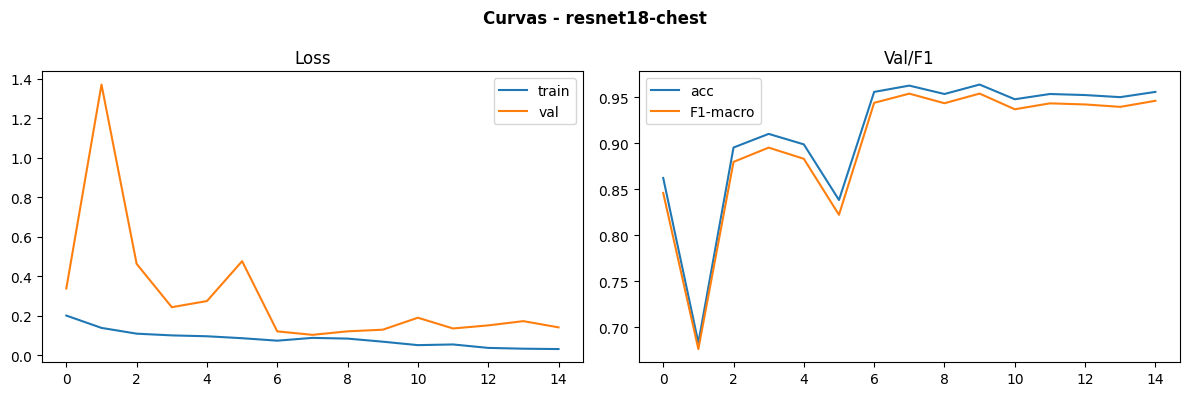


=== resnet18/chest ===
  Acc=0.9659  F1=0.9564  Sens=0.9528  Spec=0.9528  AUC=0.9900
  Inf=32.961ms  Params=11,177,538
              precision    recall  f1-score   support

      NORMAL       0.95      0.92      0.94       238
   PNEUMONIA       0.97      0.98      0.98       641

    accuracy                           0.97       879
   macro avg       0.96      0.95      0.96       879
weighted avg       0.97      0.97      0.97       879



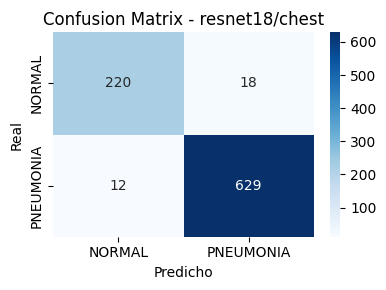

In [8]:
_mn='resnet18'
_bs=32
_ckpt=str(ckpt_chest/('resnet18_best.pt'))
_tr,_va,_te,_=make_loaders(CHEST_OUT,weighted=True,bs=_bs)
_model=build_model(_mn,N_CHEST).to(DEVICE)
_hist=train_one(_model,_tr,_va,cw=chest_cw,max_ep=50,patience=5,ckpt=_ckpt)
plot_history(_hist,'resnet18-chest')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_chest['resnet18']=compute_metrics(_model,_te,CHEST_NAMES,'resnet18/chest')
del _model;torch.cuda.empty_cache()


### HQC-CNN — Chest X-Ray (batch=16)

Ep 1:   0%|          | 0/257 [00:00<?, ?it/s]

Ep   1 | 62.5s | tr=0.3870 | va=0.3250 | acc=0.8907 | F1=0.8742


Ep 2:   0%|          | 0/257 [00:00<?, ?it/s]

Ep   2 | 35.0s | tr=0.2362 | va=0.2563 | acc=0.9112 | F1=0.8953


Ep 3:   0%|          | 0/257 [00:00<?, ?it/s]

...

Ep  13 | 34.9s | tr=0.1274 | va=0.2176 | acc=0.9146 | F1=0.8992


Ep 14:   0%|          | 0/257 [00:00<?, ?it/s]

Ep  14 | 41.9s | tr=0.1248 | va=0.2303 | acc=0.9112 | F1=0.8955


Ep 15:   0%|          | 0/257 [00:00<?, ?it/s]

Ep  15 | 33.5s | tr=0.1144 | va=0.2747 | acc=0.9009 | F1=0.8854
Early stopping ep 15


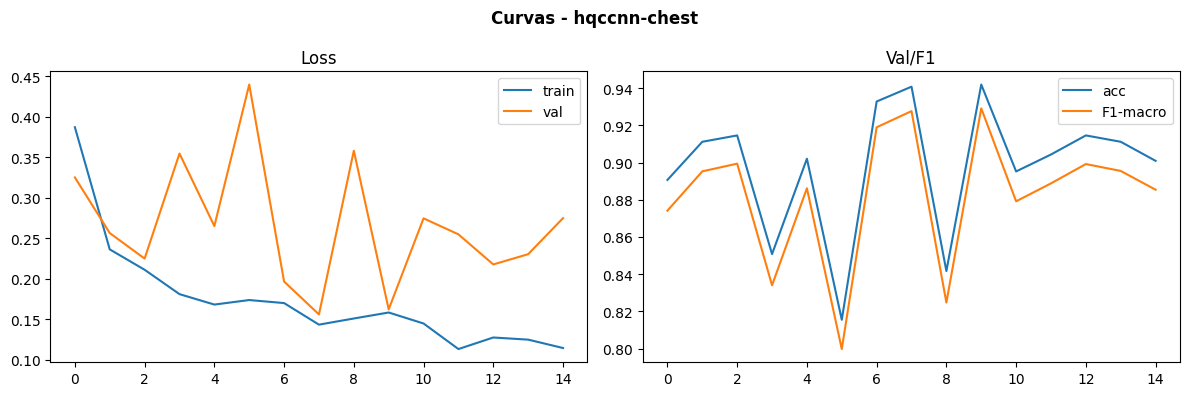


=== hqccnn/chest ===
  Acc=0.9272  F1=0.9116  Sens=0.9303  Spec=0.9303  AUC=0.9776
  Inf=18.707ms  Params=89,686
              precision    recall  f1-score   support

      NORMAL       0.82      0.94      0.87       238
   PNEUMONIA       0.98      0.92      0.95       641

    accuracy                           0.93       879
   macro avg       0.90      0.93      0.91       879
weighted avg       0.93      0.93      0.93       879



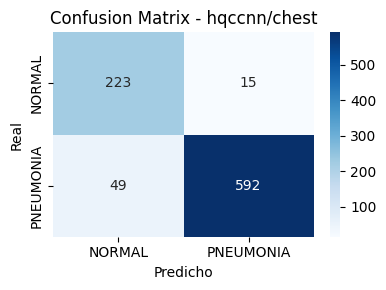

In [9]:
_mn='hqccnn'
_bs=16
_ckpt=str(ckpt_chest/('hqccnn_best.pt'))
_tr,_va,_te,_=make_loaders(CHEST_OUT,weighted=True,bs=_bs)
_model=build_model(_mn,N_CHEST).to(DEVICE)
_hist=train_one(_model,_tr,_va,cw=chest_cw,max_ep=50,patience=5,ckpt=_ckpt)
plot_history(_hist,'hqccnn-chest')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_chest['hqccnn']=compute_metrics(_model,_te,CHEST_NAMES,'hqccnn/chest')
del _model;torch.cuda.empty_cache()


### PEQML — Chest X-Ray (batch=16)

Ep 1:   0%|          | 0/257 [00:00<?, ?it/s]

Ep   1 | 68.8s | tr=0.4492 | va=0.4901 | acc=0.8542 | F1=0.8366


Ep 2:   0%|          | 0/257 [00:00<?, ?it/s]

Ep   2 | 32.4s | tr=0.3196 | va=0.5106 | acc=0.7882 | F1=0.7731


Ep 3:   0%|          | 0/257 [00:00<?, ?it/s]

...

Ep   6 | 33.8s | tr=0.2312 | va=0.2745 | acc=0.9100 | F1=0.8945


Ep 7:   0%|          | 0/257 [00:00<?, ?it/s]

Ep   7 | 32.7s | tr=0.2127 | va=0.9795 | acc=0.6492 | F1=0.6442


Ep 8:   0%|          | 0/257 [00:00<?, ?it/s]

Ep   8 | 46.0s | tr=0.2208 | va=0.4106 | acc=0.8280 | F1=0.8113
Early stopping ep 8


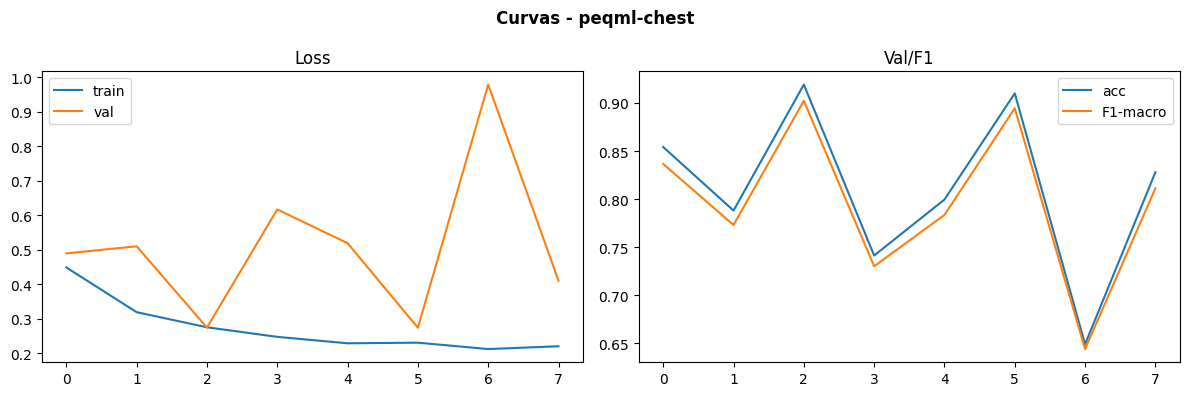


=== peqml/chest ===
  Acc=0.8953  F1=0.8752  Sens=0.9005  Spec=0.9005  AUC=0.9561
  Inf=22.360ms  Params=3,094
              precision    recall  f1-score   support

      NORMAL       0.75      0.91      0.83       238
   PNEUMONIA       0.96      0.89      0.93       641

    accuracy                           0.90       879
   macro avg       0.86      0.90      0.88       879
weighted avg       0.91      0.90      0.90       879



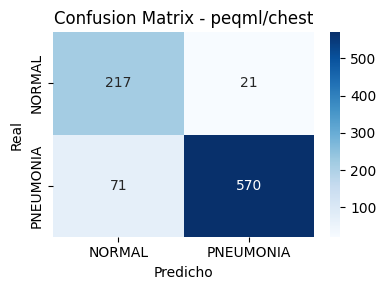

In [10]:
_mn='peqml'
_bs=16
_ckpt=str(ckpt_chest/('peqml_best.pt'))
_tr,_va,_te,_=make_loaders(CHEST_OUT,weighted=True,bs=_bs)
_model=build_model(_mn,N_CHEST).to(DEVICE)
_hist=train_one(_model,_tr,_va,cw=chest_cw,max_ep=50,patience=5,ckpt=_ckpt)
plot_history(_hist,'peqml-chest')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_chest['peqml']=compute_metrics(_model,_te,CHEST_NAMES,'peqml/chest')
del _model;torch.cuda.empty_cache()


### HQCINN-shallow — Chest X-Ray (batch=16)

Ep 1:   0%|          | 0/257 [00:00<?, ?it/s]

Ep   1 | 86.3s | tr=0.5059 | va=0.4434 | acc=0.8531 | F1=0.8287


Ep 2:   0%|          | 0/257 [00:00<?, ?it/s]

Ep   2 | 36.9s | tr=0.3283 | va=0.2964 | acc=0.9191 | F1=0.8935


Ep 3:   0%|          | 0/257 [00:00<?, ?it/s]

...

Ep   6 | 36.1s | tr=0.1967 | va=0.3946 | acc=0.8599 | F1=0.8429


Ep 7:   0%|          | 0/257 [00:00<?, ?it/s]

Ep   7 | 34.9s | tr=0.1835 | va=0.3765 | acc=0.8679 | F1=0.8509


Ep 8:   0%|          | 0/257 [00:00<?, ?it/s]

Ep   8 | 34.3s | tr=0.1720 | va=0.2737 | acc=0.8918 | F1=0.8756
Early stopping ep 8


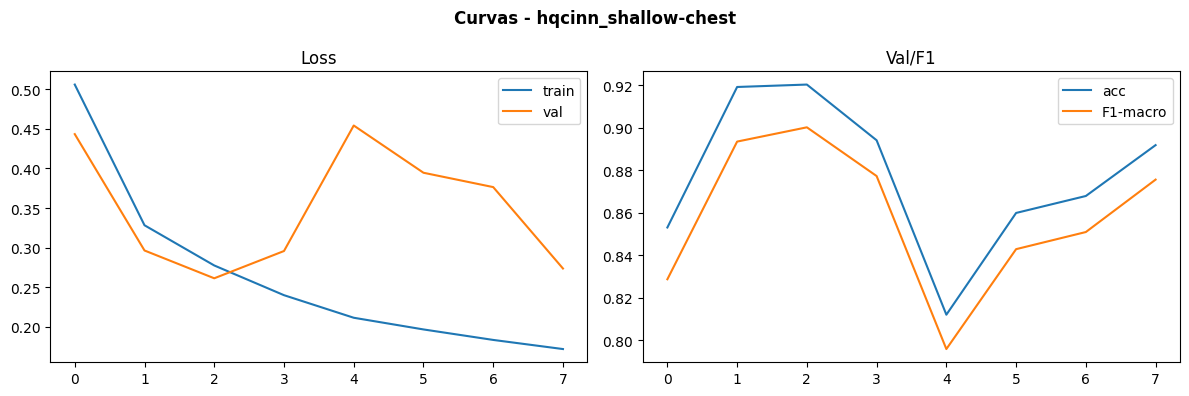


=== hqcinn_shallow/chest ===
  Acc=0.9113  F1=0.8858  Sens=0.8797  Spec=0.8797  AUC=0.9626
  Inf=18.604ms  Params=95,770
              precision    recall  f1-score   support

      NORMAL       0.85      0.81      0.83       238
   PNEUMONIA       0.93      0.95      0.94       641

    accuracy                           0.91       879
   macro avg       0.89      0.88      0.89       879
weighted avg       0.91      0.91      0.91       879



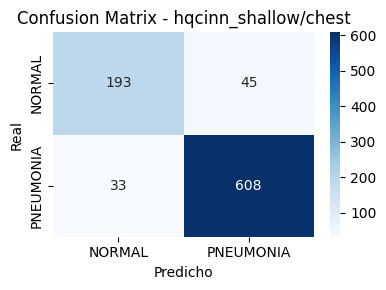

In [11]:
_mn='hqcinn_shallow'
_bs=16
_ckpt=str(ckpt_chest/('hqcinn_shallow_best.pt'))
_tr,_va,_te,_=make_loaders(CHEST_OUT,weighted=True,bs=_bs)
_model=build_model(_mn,N_CHEST).to(DEVICE)
_hist=train_one(_model,_tr,_va,cw=chest_cw,max_ep=50,patience=5,ckpt=_ckpt)
plot_history(_hist,'hqcinn_shallow-chest')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_chest['hqcinn_shallow']=compute_metrics(_model,_te,CHEST_NAMES,'hqcinn_shallow/chest')
del _model;torch.cuda.empty_cache()


### HQCINN-deep — Chest X-Ray (batch=16)

Ep 1:   0%|          | 0/257 [00:00<?, ?it/s]

Ep   1 | 67.0s | tr=0.5042 | va=0.8194 | acc=0.6025 | F1=0.6006


Ep 2:   0%|          | 0/257 [00:00<?, ?it/s]

Ep   2 | 81.2s | tr=0.3402 | va=0.4423 | acc=0.8189 | F1=0.8022


Ep 3:   0%|          | 0/257 [00:00<?, ?it/s]

...

Ep  10 | 82.7s | tr=0.1548 | va=0.2221 | acc=0.9123 | F1=0.8976


Ep 11:   0%|          | 0/257 [00:00<?, ?it/s]

Ep  11 | 82.7s | tr=0.1241 | va=0.2366 | acc=0.9100 | F1=0.8951


Ep 12:   0%|          | 0/257 [00:00<?, ?it/s]

Ep  12 | 83.4s | tr=0.1104 | va=0.3212 | acc=0.8850 | F1=0.8687
Early stopping ep 12


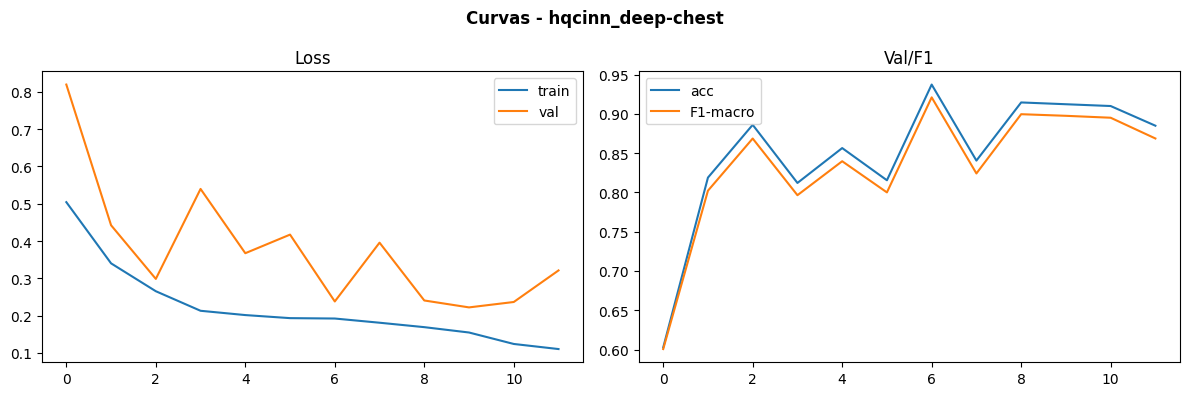


=== hqcinn_deep/chest ===
  Acc=0.9181  F1=0.8949  Sens=0.8897  Spec=0.8897  AUC=0.9366
  Inf=22.023ms  Params=96,842
              precision    recall  f1-score   support

      NORMAL       0.86      0.83      0.85       238
   PNEUMONIA       0.94      0.95      0.94       641

    accuracy                           0.92       879
   macro avg       0.90      0.89      0.89       879
weighted avg       0.92      0.92      0.92       879



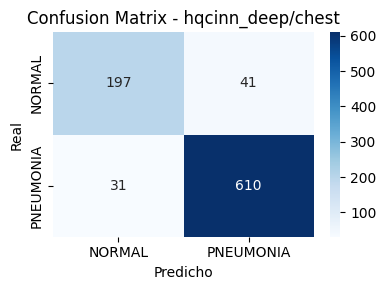

In [12]:
_mn='hqcinn_deep'
_bs=16
_ckpt=str(ckpt_chest/('hqcinn_deep_best.pt'))
_tr,_va,_te,_=make_loaders(CHEST_OUT,weighted=True,bs=_bs)
_model=build_model(_mn,N_CHEST).to(DEVICE)
_hist=train_one(_model,_tr,_va,cw=chest_cw,max_ep=50,patience=5,ckpt=_ckpt)
plot_history(_hist,'hqcinn_deep-chest')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_chest['hqcinn_deep']=compute_metrics(_model,_te,CHEST_NAMES,'hqcinn_deep/chest')
del _model;torch.cuda.empty_cache()


## DATASET 2: IQ-OTH/NCCD Lung Cancer
> batch=32 para ResNet-18, batch=16 para HQCNN

### ResNet-18 — Lung Cancer (batch=32)

Ep 1:   0%|          | 0/24 [00:00<?, ?it/s]

Ep   1 | 36.9s | tr=0.9784 | va=3.0547 | acc=0.4364 | F1=0.3602


Ep 2:   0%|          | 0/24 [00:00<?, ?it/s]

Ep   2 | 2.5s | tr=0.4533 | va=1.1058 | acc=0.5818 | F1=0.5287


Ep 3:   0%|          | 0/24 [00:00<?, ?it/s]

...

Ep  17 | 2.4s | tr=0.0482 | va=0.2030 | acc=0.9273 | F1=0.8891


Ep 18:   0%|          | 0/24 [00:00<?, ?it/s]

Ep  18 | 2.5s | tr=0.0334 | va=0.2432 | acc=0.9152 | F1=0.8718


Ep 19:   0%|          | 0/24 [00:00<?, ?it/s]

Ep  19 | 2.5s | tr=0.0432 | va=0.2086 | acc=0.9394 | F1=0.9016
Early stopping ep 19


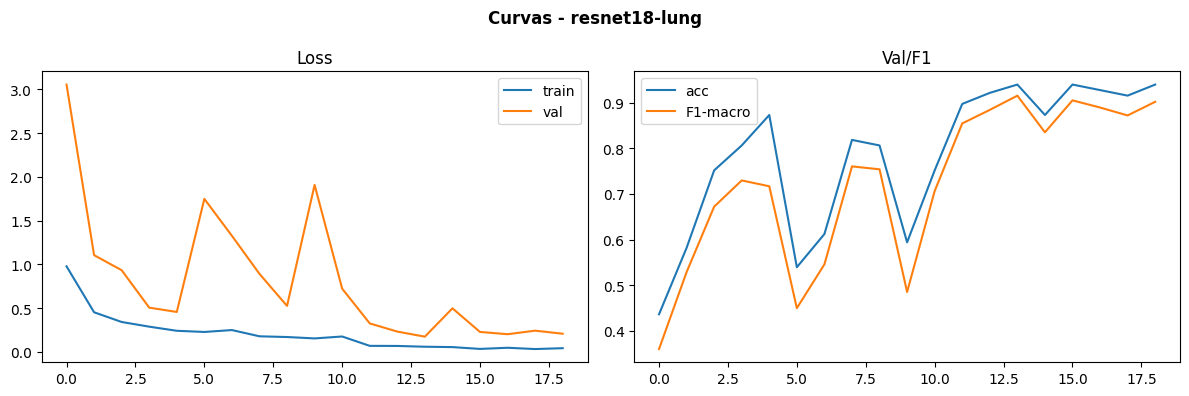


=== resnet18/lung ===
  Acc=0.9758  F1=0.9540  Sens=0.9654  Spec=0.9900  AUC=0.9955
  Inf=14.579ms  Params=11,178,051
              precision    recall  f1-score   support

      Benign       0.85      0.94      0.89        18
   Malignant       1.00      1.00      1.00        85
      Normal       0.98      0.95      0.97        62

    accuracy                           0.98       165
   macro avg       0.94      0.97      0.95       165
weighted avg       0.98      0.98      0.98       165



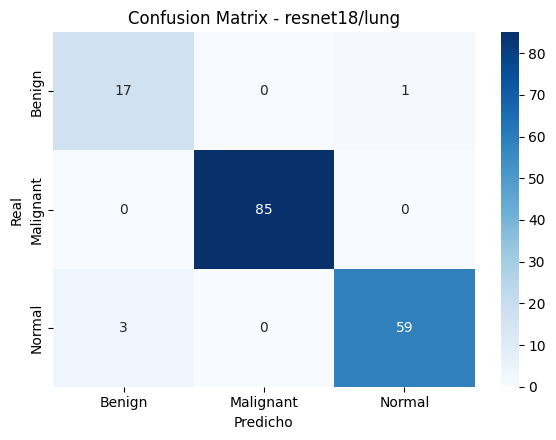

In [13]:
_mn='resnet18'
_bs=32
_ckpt=str(ckpt_lung/('resnet18_best.pt'))
_tr,_va,_te,_=make_loaders(LUNG_OUT,weighted=True,bs=_bs)
_model=build_model(_mn,N_LUNG).to(DEVICE)
_hist=train_one(_model,_tr,_va,cw=lung_cw,max_ep=50,patience=5,ckpt=_ckpt)
plot_history(_hist,'resnet18-lung')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_lung['resnet18']=compute_metrics(_model,_te,LUNG_NAMES,'resnet18/lung')
del _model;torch.cuda.empty_cache()


### HQC-CNN — Lung Cancer (batch=16)

Ep 1:   0%|          | 0/48 [00:00<?, ?it/s]

Ep   1 | 41.4s | tr=0.9601 | va=1.2905 | acc=0.1091 | F1=0.0656


Ep 2:   0%|          | 0/48 [00:00<?, ?it/s]

Ep   2 | 6.0s | tr=0.9192 | va=1.3871 | acc=0.1091 | F1=0.0656


Ep 3:   0%|          | 0/48 [00:00<?, ?it/s]

...

Ep  12 | 6.3s | tr=0.8194 | va=1.3218 | acc=0.2667 | F1=0.2303


Ep 13:   0%|          | 0/48 [00:00<?, ?it/s]

Ep  13 | 6.1s | tr=0.7845 | va=1.3257 | acc=0.2970 | F1=0.2527


Ep 14:   0%|          | 0/48 [00:00<?, ?it/s]

Ep  14 | 6.1s | tr=0.7512 | va=1.3383 | acc=0.2970 | F1=0.2527
Early stopping ep 14


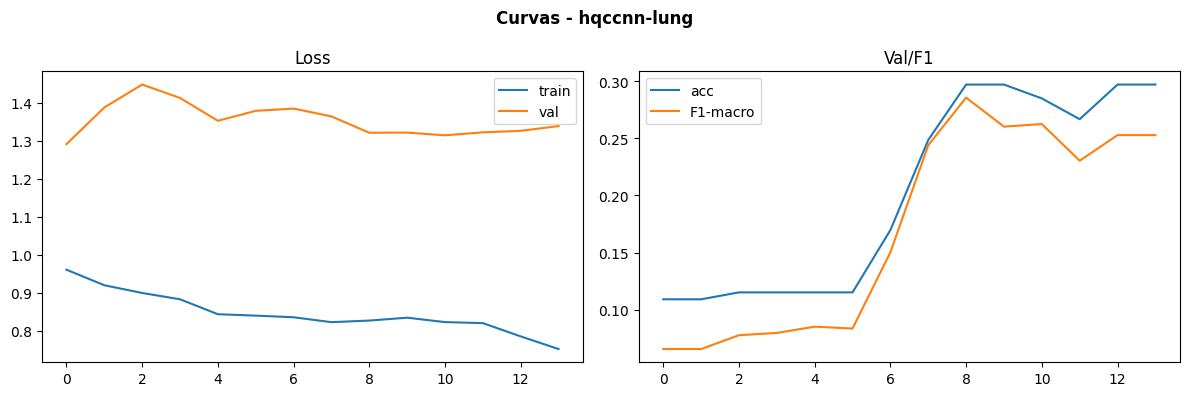


=== hqccnn/lung ===
  Acc=0.2909  F1=0.2902  Sens=0.4480  Spec=0.7299  AUC=0.6111
  Inf=17.427ms  Params=89,691
              precision    recall  f1-score   support

      Benign       0.13      0.94      0.23        18
   Malignant       1.00      0.27      0.43        85
      Normal       0.62      0.13      0.21        62

    accuracy                           0.29       165
   macro avg       0.58      0.45      0.29       165
weighted avg       0.76      0.29      0.32       165



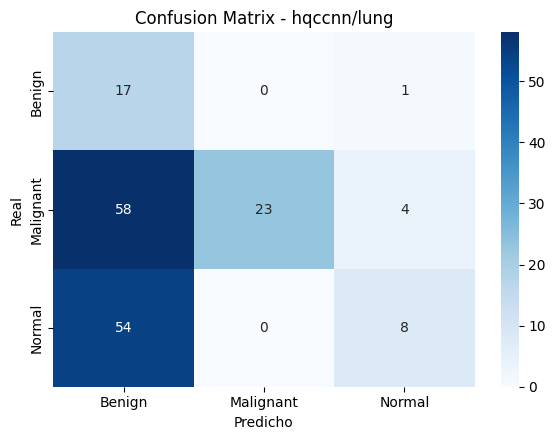

In [14]:
_mn='hqccnn'
_bs=16
_ckpt=str(ckpt_lung/('hqccnn_best.pt'))
_tr,_va,_te,_=make_loaders(LUNG_OUT,weighted=True,bs=_bs)
_model=build_model(_mn,N_LUNG).to(DEVICE)
_hist=train_one(_model,_tr,_va,cw=lung_cw,max_ep=50,patience=5,ckpt=_ckpt)
plot_history(_hist,'hqccnn-lung')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_lung['hqccnn']=compute_metrics(_model,_te,LUNG_NAMES,'hqccnn/lung')
del _model;torch.cuda.empty_cache()


### PEQML — Lung Cancer (batch=16)

Ep 1:   0%|          | 0/48 [00:00<?, ?it/s]

Ep   1 | 21.8s | tr=1.1328 | va=1.1084 | acc=0.5091 | F1=0.2249


Ep 2:   0%|          | 0/48 [00:00<?, ?it/s]

Ep   2 | 6.7s | tr=1.0653 | va=1.1602 | acc=0.1091 | F1=0.0656


Ep 3:   0%|          | 0/48 [00:00<?, ?it/s]

...

Ep   4 | 7.1s | tr=0.9726 | va=1.2045 | acc=0.1091 | F1=0.0656


Ep 5:   0%|          | 0/48 [00:00<?, ?it/s]

Ep   5 | 6.7s | tr=0.9347 | va=1.2645 | acc=0.1091 | F1=0.0656


Ep 6:   0%|          | 0/48 [00:00<?, ?it/s]

Ep   6 | 7.0s | tr=0.9144 | va=1.2745 | acc=0.1091 | F1=0.0656
Early stopping ep 6


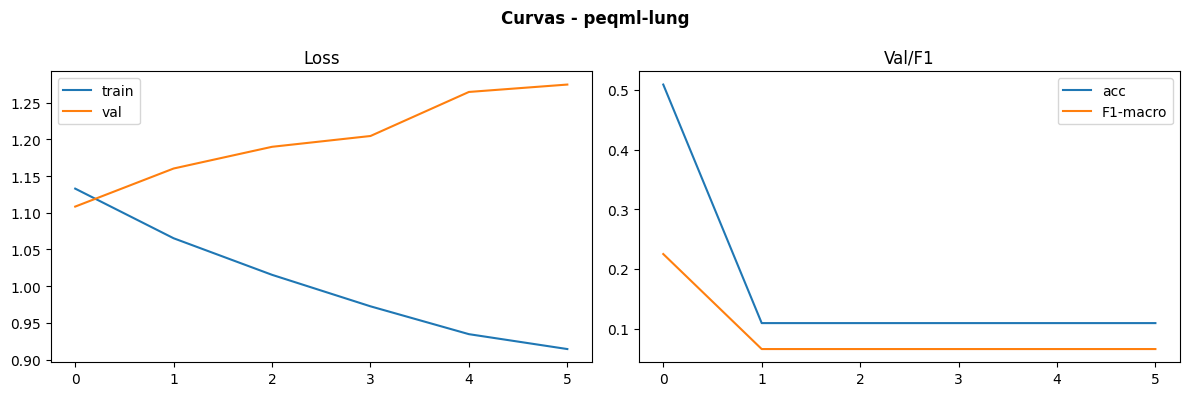


=== peqml/lung ===
  Acc=0.5152  F1=0.2267  Sens=0.3333  Spec=0.6667  AUC=0.6136
  Inf=16.154ms  Params=3,099
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00        18
   Malignant       0.52      1.00      0.68        85
      Normal       0.00      0.00      0.00        62

    accuracy                           0.52       165
   macro avg       0.17      0.33      0.23       165
weighted avg       0.27      0.52      0.35       165



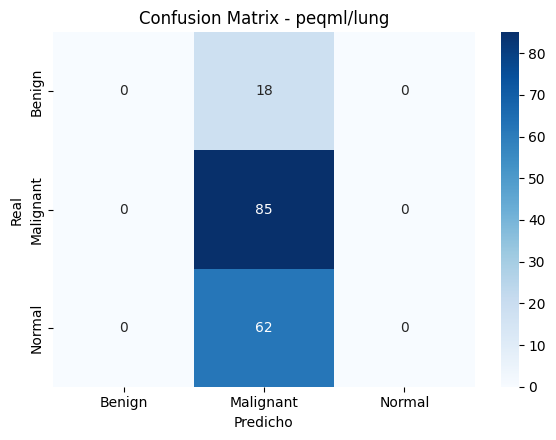

In [15]:
_mn='peqml'
_bs=16
_ckpt=str(ckpt_lung/('peqml_best.pt'))
_tr,_va,_te,_=make_loaders(LUNG_OUT,weighted=True,bs=_bs)
_model=build_model(_mn,N_LUNG).to(DEVICE)
_hist=train_one(_model,_tr,_va,cw=lung_cw,max_ep=50,patience=5,ckpt=_ckpt)
plot_history(_hist,'peqml-lung')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_lung['peqml']=compute_metrics(_model,_te,LUNG_NAMES,'peqml/lung')
del _model;torch.cuda.empty_cache()


### HQCINN-shallow — Lung Cancer (batch=16)

Ep 1:   0%|          | 0/48 [00:00<?, ?it/s]

Ep   1 | 25.5s | tr=0.9612 | va=1.2884 | acc=0.1333 | F1=0.1010


Ep 2:   0%|          | 0/48 [00:00<?, ?it/s]

Ep   2 | 6.8s | tr=0.9460 | va=1.3651 | acc=0.1576 | F1=0.1248


Ep 3:   0%|          | 0/48 [00:00<?, ?it/s]

...

Ep  35 | 6.6s | tr=0.7008 | va=0.9528 | acc=0.5758 | F1=0.4231


Ep 36:   0%|          | 0/48 [00:00<?, ?it/s]

Ep  36 | 6.9s | tr=0.6547 | va=0.9617 | acc=0.5515 | F1=0.4096


Ep 37:   0%|          | 0/48 [00:00<?, ?it/s]

Ep  37 | 7.3s | tr=0.6522 | va=0.9599 | acc=0.5697 | F1=0.4199
Early stopping ep 37


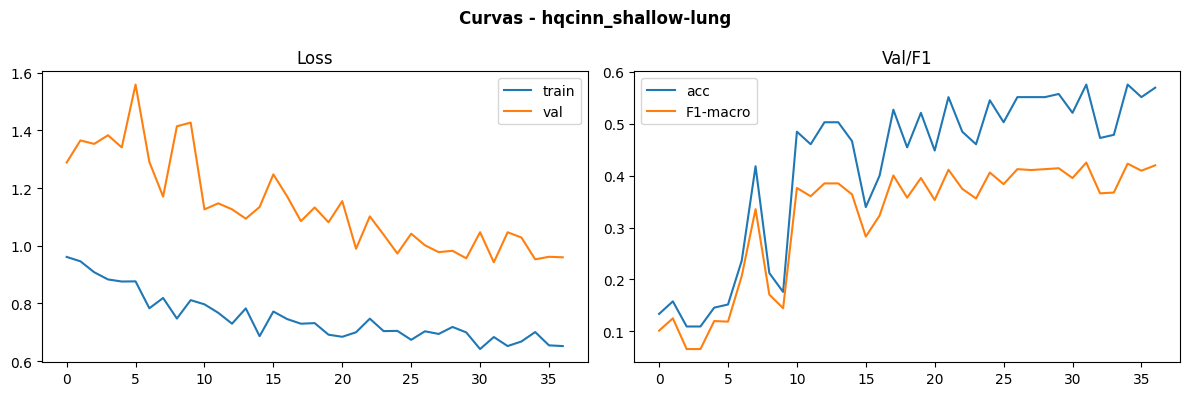


=== hqcinn_shallow/lung ===
  Acc=0.4970  F1=0.3806  Sens=0.5843  Spec=0.7985  AUC=0.7994
  Inf=16.547ms  Params=95,775
              precision    recall  f1-score   support

      Benign       0.19      1.00      0.32        18
   Malignant       0.90      0.75      0.82        85
      Normal       0.00      0.00      0.00        62

    accuracy                           0.50       165
   macro avg       0.36      0.58      0.38       165
weighted avg       0.49      0.50      0.46       165



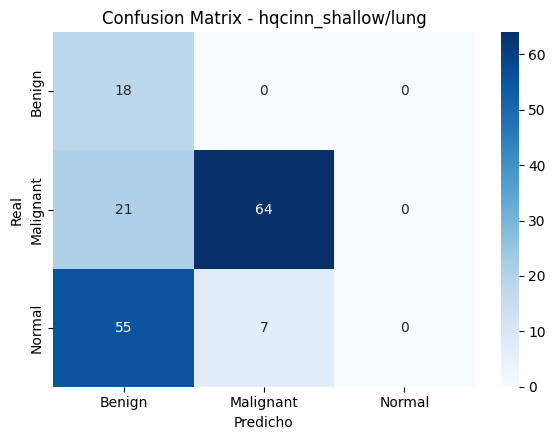

In [16]:
_mn='hqcinn_shallow'
_bs=16
_ckpt=str(ckpt_lung/('hqcinn_shallow_best.pt'))
_tr,_va,_te,_=make_loaders(LUNG_OUT,weighted=True,bs=_bs)
_model=build_model(_mn,N_LUNG).to(DEVICE)
_hist=train_one(_model,_tr,_va,cw=lung_cw,max_ep=50,patience=5,ckpt=_ckpt)
plot_history(_hist,'hqcinn_shallow-lung')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_lung['hqcinn_shallow']=compute_metrics(_model,_te,LUNG_NAMES,'hqcinn_shallow/lung')
del _model;torch.cuda.empty_cache()


### HQCINN-deep — Lung Cancer (batch=16)

Ep 1:   0%|          | 0/48 [00:00<?, ?it/s]

Ep   1 | 42.2s | tr=0.9812 | va=1.2407 | acc=0.1091 | F1=0.0656


Ep 2:   0%|          | 0/48 [00:00<?, ?it/s]

Ep   2 | 15.3s | tr=0.9516 | va=1.1646 | acc=0.2909 | F1=0.2484


Ep 3:   0%|          | 0/48 [00:00<?, ?it/s]

...

Ep  11 | 15.3s | tr=0.6837 | va=1.1369 | acc=0.4667 | F1=0.3773


Ep 12:   0%|          | 0/48 [00:00<?, ?it/s]

Ep  12 | 16.0s | tr=0.6486 | va=1.1070 | acc=0.4727 | F1=0.3721


Ep 13:   0%|          | 0/48 [00:00<?, ?it/s]

Ep  13 | 16.0s | tr=0.6671 | va=1.1523 | acc=0.4424 | F1=0.3542
Early stopping ep 13


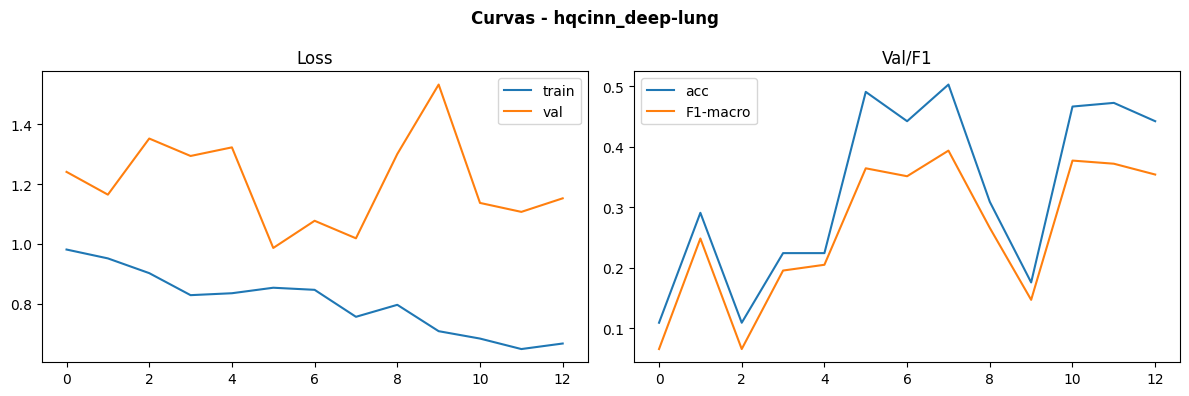


=== hqcinn_deep/lung ===
  Acc=0.4182  F1=0.3423  Sens=0.5085  Spec=0.7424  AUC=0.7003
  Inf=25.091ms  Params=96,849
              precision    recall  f1-score   support

      Benign       0.18      0.89      0.29        18
   Malignant       0.70      0.59      0.64        85
      Normal       1.00      0.05      0.09        62

    accuracy                           0.42       165
   macro avg       0.63      0.51      0.34       165
weighted avg       0.76      0.42      0.40       165



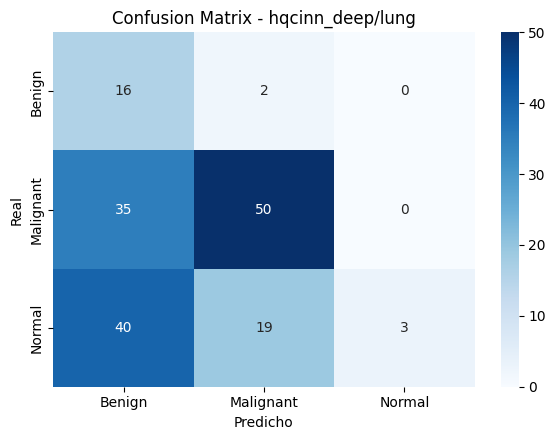

In [17]:
_mn='hqcinn_deep'
_bs=16
_ckpt=str(ckpt_lung/('hqcinn_deep_best.pt'))
_tr,_va,_te,_=make_loaders(LUNG_OUT,weighted=True,bs=_bs)
_model=build_model(_mn,N_LUNG).to(DEVICE)
_hist=train_one(_model,_tr,_va,cw=lung_cw,max_ep=50,patience=5,ckpt=_ckpt)
plot_history(_hist,'hqcinn_deep-lung')
_model.load_state_dict(torch.load(_ckpt,map_location=DEVICE))
results_lung['hqcinn_deep']=compute_metrics(_model,_te,LUNG_NAMES,'hqcinn_deep/lung')
del _model;torch.cuda.empty_cache()


## 7 · Tablas comparativas


=== CHEST ===
                Accuracy  F1-macro  Sensibilidad  Especificidad     AUC  Inf(ms)    Params
Modelo                                                                                    
resnet18          0.9659    0.9564        0.9528         0.9528  0.9900   32.961  11177538
hqccnn            0.9272    0.9116        0.9303         0.9303  0.9776   18.707     89686
peqml             0.8953    0.8752        0.9005         0.9005  0.9561   22.360      3094
hqcinn_shallow    0.9113    0.8858        0.8797         0.8797  0.9626   18.604     95770
hqcinn_deep       0.9181    0.8949        0.8897         0.8897  0.9366   22.023     96842


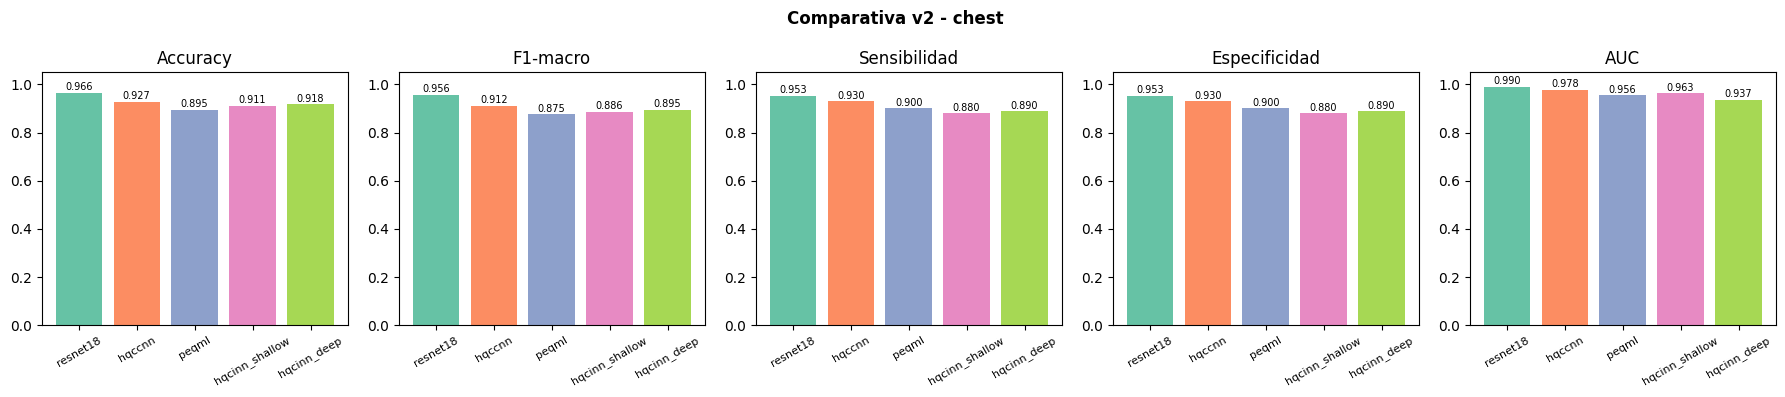


=== LUNG ===
                Accuracy  F1-macro  Sensibilidad  Especificidad     AUC  Inf(ms)    Params
Modelo                                                                                    
resnet18          0.9758    0.9540        0.9654         0.9900  0.9955   14.579  11178051
hqccnn            0.2909    0.2902        0.4480         0.7299  0.6111   17.427     89691
peqml             0.5152    0.2267        0.3333         0.6667  0.6136   16.154      3099
hqcinn_shallow    0.4970    0.3806        0.5843         0.7985  0.7994   16.547     95775
hqcinn_deep       0.4182    0.3423        0.5085         0.7424  0.7003   25.091     96849


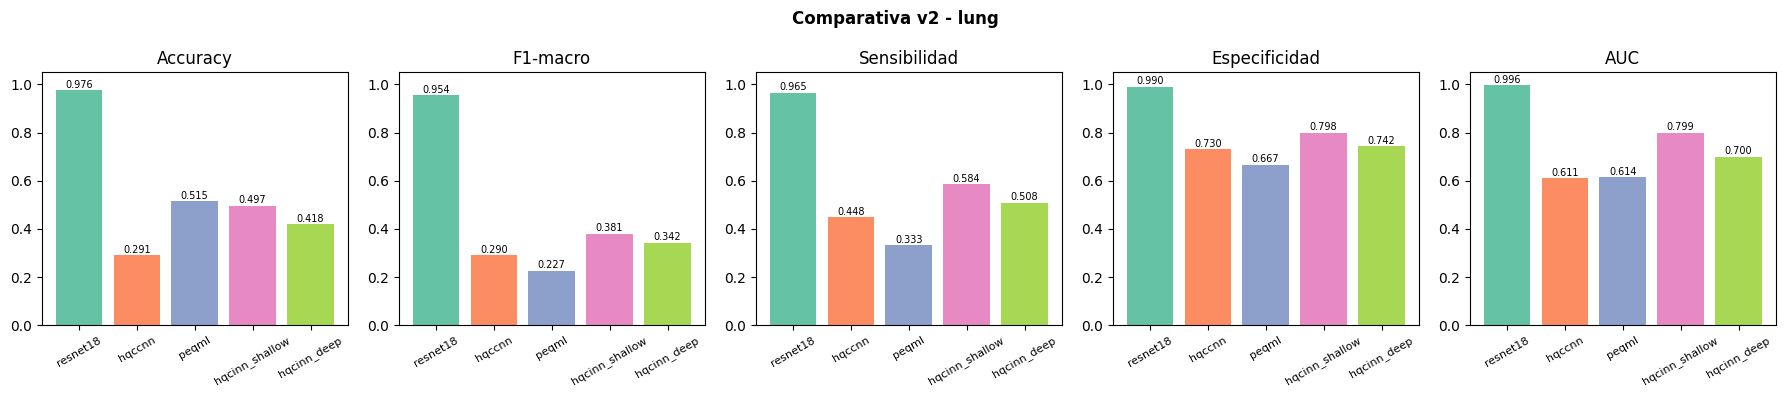

In [18]:
all_res={'chest':results_chest,'lung':results_lung}
for dsname in ['chest','lung']:
    rows=[{'Modelo':mn,'Accuracy':round(r['acc'],4),'F1-macro':round(r['f1'],4),'Sensibilidad':round(r['sens'],4),'Especificidad':round(r['spec'],4),'AUC':round(r['auc'],4),'Inf(ms)':round(r['inf_ms'],3),'Params':r['params']} for mn,r in all_res[dsname].items()]
    df=pd.DataFrame(rows).set_index('Modelo')
    print('\n===',dsname.upper(),'===');print(df.to_string())
    df.to_csv(BASE_DIR/('resultados_v2_'+dsname+'.csv'))
    mets=['Accuracy','F1-macro','Sensibilidad','Especificidad','AUC']
    fig,axes=plt.subplots(1,len(mets),figsize=(18,4));fig.suptitle('Comparativa v2 - '+dsname,fontweight='bold')
    pal=sns.color_palette('Set2',len(df))
    for ax,met in zip(axes,mets):
        vals=df[met].values;bars=ax.bar(df.index,vals,color=pal)
        ax.set_title(met);ax.set_ylim(0,1.05);ax.tick_params(axis='x',rotation=30,labelsize=8)
        for bar,v in zip(bars,vals): ax.text(bar.get_x()+bar.get_width()/2,v+0.01,'{:.3f}'.format(v),ha='center',fontsize=7)
    plt.tight_layout();plt.show()


## 8 · Analisis estadistico — ANOVA + t-Student + IC 95% (5-fold CV segun PPI)

In [19]:
# 5-fold CV estratificado sobre test para IC 95% (segun PPI)
from sklearn.model_selection import StratifiedKFold

def cv_f1_ci(preds,labs,n_splits=5,seed=42):
    skf=StratifiedKFold(n_splits=n_splits,shuffle=True,random_state=seed)
    idx=np.arange(len(labs))
    scores=[f1_score(np.array(labs)[te],np.array(preds)[te],average='macro',zero_division=0)
            for _,te in skf.split(idx,labs)]
    return float(np.mean(scores)),np.percentile(scores,[2.5,97.5])

all_res={'chest':results_chest,'lung':results_lung}
for dsname in ['chest','lung']:
    print('\n===',dsname.upper(),'===')
    dists={}
    for mn,r in all_res[dsname].items():
        mean_f1,ci=cv_f1_ci(r['preds'],r['labs'])
        dists[mn]=[f1_score(np.array(r['labs'])[te],np.array(r['preds'])[te],average='macro',zero_division=0)
                   for _,te in StratifiedKFold(5,shuffle=True,random_state=42).split(np.arange(len(r['labs'])),r['labs'])]
        print('  {:<20} F1={:.4f}  IC95=[{:.4f},{:.4f}]'.format(mn,r['f1'],ci[0],ci[1]))
    f_stat,p_anova=stats.f_oneway(*dists.values())
    print('  ANOVA F={:.4f} p={:.6f} sig={}'.format(f_stat,p_anova,p_anova<0.05))
    pair_rows=[]
    for m1,m2 in combinations(list(dists.keys()),2):
        t,p=stats.ttest_ind(dists[m1],dists[m2])
        sig='*' if p<0.05 else ''
        pair_rows.append({'Par':m1+' vs '+m2,'t':round(t,4),'p':round(p,6),'sig':sig})
        print('  {} vs {}: t={:.4f} p={:.6f} {}'.format(m1,m2,t,p,sig))
    pd.DataFrame(pair_rows).to_csv(BASE_DIR/('ttest_v2_'+dsname+'.csv'),index=False)



=== CHEST ===
  resnet18             F1=0.9564  IC95=[0.9428,0.9706]
  hqccnn               F1=0.9116  IC95=[0.8719,0.9500]
  peqml                F1=0.8752  IC95=[0.8550,0.9183]
  hqcinn_shallow       F1=0.8858  IC95=[0.8545,0.9104]
  hqcinn_deep          F1=0.8949  IC95=[0.8693,0.9221]
  ANOVA F=8.0704 p=0.000482 sig=True
  resnet18 vs hqccnn: t=2.7251 p=0.026041 *
  resnet18 vs peqml: t=6.0253 p=0.000314 *
  resnet18 vs hqcinn_shallow: t=5.9379 p=0.000347 *
  resnet18 vs hqcinn_deep: t=5.7357 p=0.000436 *
  hqccnn vs peqml: t=1.8359 p=0.103695 
  hqccnn vs hqcinn_shallow: t=1.3870 p=0.202859 
  hqccnn vs hqcinn_deep: t=0.9325 p=0.378383 
  peqml vs hqcinn_shallow: t=-0.6279 p=0.547548 
  peqml vs hqcinn_deep: t=-1.2557 p=0.244668 
  hqcinn_shallow vs hqcinn_deep: t=-0.6481 p=0.535090 

=== LUNG ===
  resnet18             F1=0.9540  IC95=[0.8718,1.0000]
  hqccnn               F1=0.2902  IC95=[0.2382,0.3371]
  peqml                F1=0.2267  IC95=[0.2267,0.2267]
  hqcinn_shallow     

D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\envprueba\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


## 9 · Guardar JSON consolidado

In [20]:
summary={}
for ds in ['chest','lung']:
    summary[ds]={mn:{k:v for k,v in r.items() if k not in ('preds','labs','probs')} for mn,r in all_res[ds].items()}
out=BASE_DIR/'resultados_v2.json'
with open(out,'w') as f: json.dump(summary,f,indent=2,default=str)
print('Guardado:',out)


Guardado: D:\CURSOS 2026 - 1\Cyberseguridad\jupyterlab\investigacion\resultados_v2.json
